In [23]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('../../../data/processed/land_dataset_final_v3_noisy_3.csv')

In [25]:
df.shape

(9060, 234)

In [26]:
# # Efficient for very large datasets
# random_indices = np.random.choice(df.index, size=3000, replace=False)
# fast_sample = df.loc[random_indices]

In [27]:
# df = fast_sample.copy()

In [28]:
X = df.drop(columns=["price_per_m2", "price", "longitude", "latitude", "geometry"])
y = df['price_per_m2']

In [29]:
# Add mean, max, median, min of price_per_m2 for each row, grouped by h_id
agg_stats = df.groupby('h_id')['price_per_m2'].agg(['mean', 'max', 'median', 'min'])
agg_stats = agg_stats.rename(columns={
    'mean': 'h_id_price_mean',
    'max': 'h_id_price_max',
    'median': 'h_id_price_median',
    'min': 'h_id_price_min'
})

# Merge these stats back to the original dataframe
df = df.merge(agg_stats, left_on='h_id', right_index=True)

In [30]:
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Categorical columns: ['address_subdivision', 'address_locality', 'address_line_2', 'h_id']
Numerical columns: ['land_area', 'near_Koh_Pich_in_km', 'Koh_Pich_nearest', 'Koh_Pich_1_2km', 'Koh_Pich_2_3km', 'Koh_Pich_3_5km', 'Koh_Pich_5_10km', 'near_Russian_Market_in_km', 'Russian_Market_nearest', 'Russian_Market_1_2km', 'Russian_Market_2_3km', 'Russian_Market_3_5km', 'Russian_Market_5_10km', 'near_AEON_Mall_1_in_km', 'AEON_Mall_1_nearest', 'AEON_Mall_1_1_2km', 'AEON_Mall_1_2_3km', 'AEON_Mall_1_3_5km', 'AEON_Mall_1_5_10km', 'near_AEON_Mall_2_in_km', 'AEON_Mall_2_nearest', 'AEON_Mall_2_1_2km', 'AEON_Mall_2_2_3km', 'AEON_Mall_2_3_5km', 'AEON_Mall_2_5_10km', 'near_AEON_Mall_3_in_km', 'AEON_Mall_3_nearest', 'AEON_Mall_3_1_2km', 'AEON_Mall_3_2_3km', 'AEON_Mall_3_3_5km', 'AEON_Mall_3_5_10km', 'near_Bassac_Lane_in_km', 'Bassac_Lane_nearest', 'Bassac_Lane_1_2km', 'Bassac_Lane_2_3km', 'Bassac_Lane_3_5km', 'Bassac_Lane_5_10km', 'near_Koh_Norea_in_km', 'Koh_Norea_nearest', 'Koh_Norea_1_2km', 'Koh_Nor

In [31]:
encoders = {}
X_encoded = X.copy()

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))  # Handle missing values
    encoders[col] = le  # Store encoder

# 4. Save encoders for future use


In [32]:
joblib.dump(encoders, '../../../data/processed/label_encoders_v3.pkl')

['../../../data/processed/label_encoders_v3.pkl']

In [33]:
mi_scores = mutual_info_regression(X_encoded, y)
feature_scores = pd.Series(mi_scores, index=X_encoded.columns)
selected_features = feature_scores.nlargest(15).index.tolist()

In [34]:
selected_features

['address_line_2',
 'h_id',
 'n_gas_station_5km',
 'n_seven_eleven_5km',
 'n_cafe_5km',
 'near_Olympic_Stadium_in_km',
 'near_Phsar_Tmey_in_km',
 'n_gas_station_in_3km_to_5km',
 'near_Vattanac_Tower_in_km',
 'n_secondary_school_5km',
 'n_cafe_in_3km_to_5km',
 'n_primary_school_5km',
 'n_primary_school_in_3km_to_5km',
 'near_Phsar_Chas_in_km',
 'near_Royal_Palace_in_km']

In [35]:
final_data = pd.DataFrame()
for col in selected_features:
    if col in categorical_cols:
        final_data[col] = X_encoded[col]  # Use encoded version
    else:
        final_data[col] = X[col]  # Keep numerical as-is

In [36]:
final_data['price_per_m2'] = y

In [37]:
final_data

,address_line_2,h_id,n_gas_station_5km,n_seven_eleven_5km,n_cafe_5km,near_Olympic_Stadium_in_km,near_Phsar_Tmey_in_km,n_gas_station_in_3km_to_5km,near_Vattanac_Tower_in_km,n_secondary_school_5km,n_cafe_in_3km_to_5km,n_primary_school_5km,n_primary_school_in_3km_to_5km,near_Phsar_Chas_in_km,near_Royal_Palace_in_km,price_per_m2
0,78,450,172.0,32.0,167.0,3.009921,3.933300,109,3.990249,72.0,120,92.0,47,4.954318,5.059849,3249.773855
1,48,476,114.0,32.0,144.0,3.096088,3.959717,61,4.141177,61.0,86,62.0,37,5.024695,3.797103,2357.960918
2,45,351,149.0,25.0,137.0,3.067701,3.057833,76,3.016462,62.0,80,69.0,45,3.959881,4.774171,3466.326691
3,45,464,170.0,34.0,169.0,2.073850,3.007511,85,3.240525,76.0,94,83.0,45,3.072308,3.878483,2979.374452
4,14,427,48.0,21.0,96.0,5.169446,3.958012,40,3.873280,34.0,75,25.0,23,2.996484,2.753486,5133.654419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9055,0,822,0.0,3.0,3.0,15.002912,14.024661,0,14.069084,0.0,0,-0.0,0,13.810265,15.019705,649.765695
9056,66,378,16.0,7.0,10.0,11.993371,10.933097,15,10.119484,2.0,8,1.0,2,10.069962,11.026332,158.350974
9057,59,596,1.0,1.0,1.0,17.865568,17.995979,1,18.185008,0.0,0,0.0,0,19.210830,20.031367,281.534392
9058,26,653,14.0,3.0,5.0,14.210714,14.889846,12,15.082163,3.0,6,3.0,2,15.984230,16.174411,511.506551


In [38]:
# final_data.to_csv('../../../data/preprocessed/selected_features_dataset_V3.csv', index=False)
print(f"Saved dataset with {len(selected_features)} selected features")

Saved dataset with 15 selected features


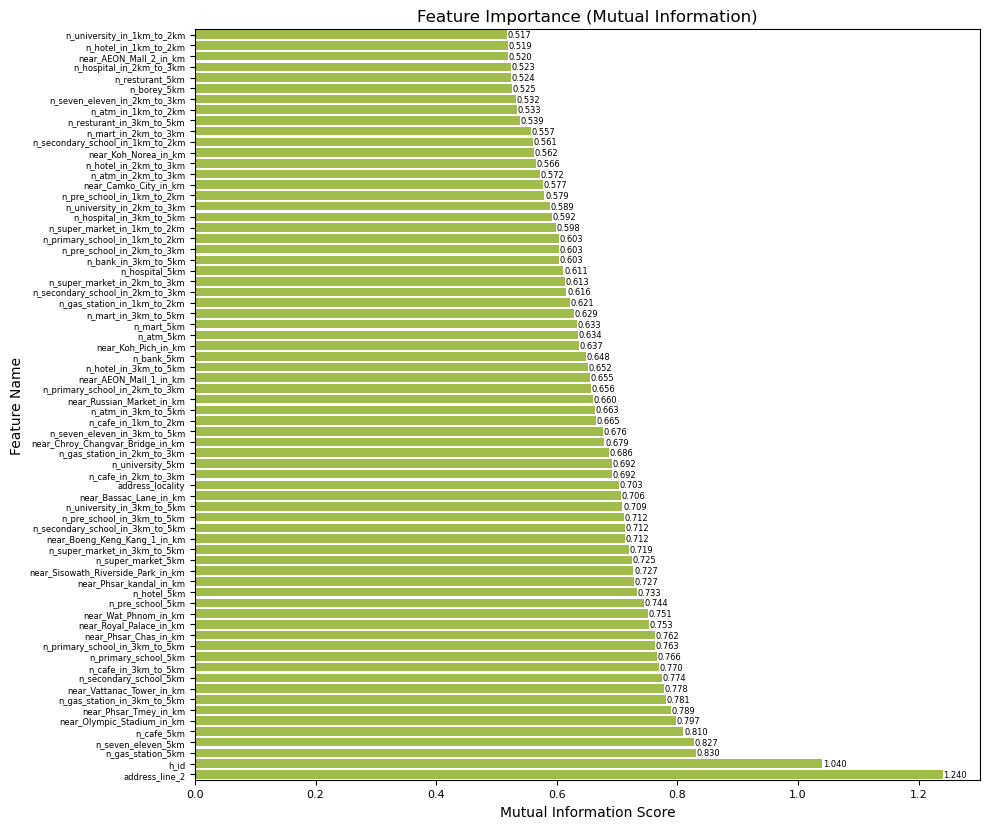

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort feature scores by importance
sorted_features = feature_scores.sort_values(ascending=True).tail(70)

# Dynamically adjust height: ~0.1–0.15 inches per feature
plt.figure(figsize=(10, len(sorted_features) * 0.12))

ax = sns.barplot(
    x=sorted_features.values,
    y=sorted_features.index,
    color="#a9cf38"
)

plt.title("Feature Importance (Mutual Information)", fontsize=12)
plt.xlabel("Mutual Information Score", fontsize=10)
plt.ylabel("Feature Name", fontsize=10)

# Smaller font for value labels and tighter spacing
for i, v in enumerate(sorted_features.values):
    ax.text(v + 0.001, i, f"{v:.3f}", color='black', va='center', fontsize=6)

plt.xticks(fontsize=8)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.savefig('feature_importance_all_200_features.png', dpi=300)
plt.show()


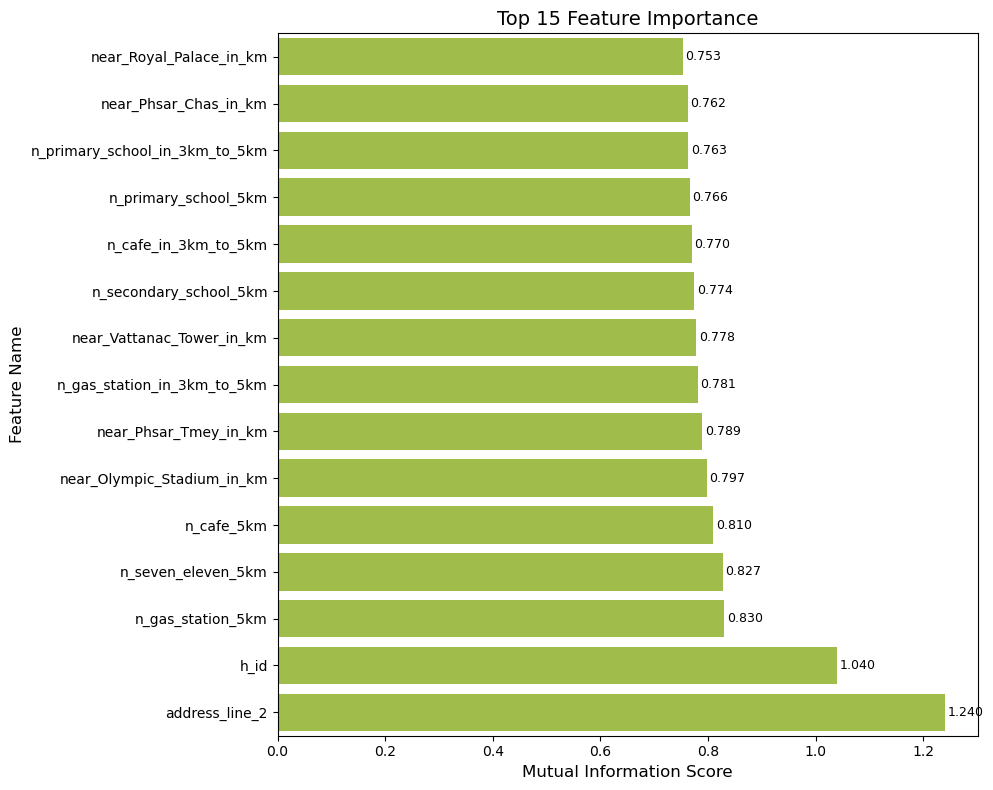

In [ ]:
plt.figure(figsize=(10, 8))
top_features = feature_scores.nlargest(15).sort_values(ascending=True)
ax = sns.barplot(x=top_features.values, y=top_features.index, color="#a9cf38")

plt.title("Top 15 Feature Importance", fontsize=14)
plt.xlabel("Mutual Information Score", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
for i, v in enumerate(top_features.values):
    ax.text(v + 0.005, i, f"{v:.3f}", color='black', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300)
plt.show()

In [40]:
top_features

near_Royal_Palace_in_km           0.752572
near_Phsar_Chas_in_km             0.762400
n_primary_school_in_3km_to_5km    0.763259
n_primary_school_5km              0.765677
n_cafe_in_3km_to_5km              0.769961
n_secondary_school_5km            0.773760
near_Vattanac_Tower_in_km         0.778124
n_gas_station_in_3km_to_5km       0.780954
near_Phsar_Tmey_in_km             0.789301
near_Olympic_Stadium_in_km        0.797196
n_cafe_5km                        0.809895
n_seven_eleven_5km                0.826857
n_gas_station_5km                 0.830063
h_id                              1.039773
address_line_2                    1.239554
dtype: float64

In [41]:
# def preprocess_new_data(new_df, encoder_path='feature_encoders.pkl'):
#     """Preprocess new data using saved encoders"""
#     # Load saved encoders
#     encoders = joblib.load(encoder_path)
    
#     # Process categorical features
#     new_processed = new_df.copy()
#     for col, encoder in encoders.items():
#         # Handle unseen categories by filling with a placeholder
#         new_processed[col] = new_df[col].map(lambda x: x if x in encoder.classes_ else 'UNK')
#         new_processed[col] = encoder.transform(new_processed[col])
    
#     return new_processed

# # Usage example:
# # new_data_processed = preprocess_new_data(new_df)